In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully.")

try:
    df = pd.read_csv("retail_superstore.csv")
    print("Success: Loaded 'retail_superstore.csv' from local directory.")
except FileNotFoundError:
    print("Notice: Local file not found. Generating a robust synthetic Superstore dataset for demonstration...")
    np.random.seed(42)
    n_rows = 10000
    
    dates = pd.date_range(start="2023-01-01", end="2025-12-31", freq="D")
    df = pd.DataFrame({
        'Order_ID': [f"ORD-{i:05d}" for i in range(1, n_rows + 1)],
        'Order_Date': np.random.choice(dates, n_rows),
        'Customer_ID': np.random.randint(10000, 10500, n_rows),
        'Category': np.random.choice(['Furniture', 'Office Supplies', 'Technology'], n_rows, p=[0.3, 0.45, 0.25]),
        'Sub_Category': np.random.choice(['Chairs', 'Tables', 'Binders', 'Phones', 'Storage', 'Art', 'Accessories'], n_rows),
        'Sales': np.random.exponential(scale=180, size=n_rows) + 15,
        'Quantity': np.random.randint(1, 10, n_rows),
        'Discount': np.random.choice([0.0, 0.1, 0.2, 0.3, 0.4, 0.5], n_rows, p=[0.4, 0.2, 0.15, 0.1, 0.1, 0.05]),
    })
    base_margin = np.where(df['Category'] == 'Technology', 0.35, 0.20)
    df['Profit'] = df['Sales'] * (base_margin - df['Discount']) * np.random.uniform(0.8, 1.2, n_rows)

print(f"Dataset Initial Shape: {df.shape}")

Libraries imported successfully.
Notice: Local file not found. Generating a robust synthetic Superstore dataset for demonstration...
Dataset Initial Shape: (10000, 9)


In [18]:
print("--- DATA INSPECTION & CLEANING ---")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)
df['Sales'] = df['Sales'].fillna(df['Sales'].median())
df['Profit'] = df['Profit'].fillna(df['Profit'].median())

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Year_Month'] = df['Order_Date'].dt.to_period('M').astype(str)
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

print(f"Cleaned Dataset Shape: {df.shape}")
df.head(3)

--- DATA INSPECTION & CLEANING ---
Order_ID        0
Order_Date      0
Customer_ID     0
Category        0
Sub_Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64
Cleaned Dataset Shape: (10000, 13)


,Order_ID,Order_Date,Customer_ID,Category,Sub_Category,Sales,Quantity,Discount,Profit,Year,Month,Year_Month,Profit_Margin
0,ORD-00001,2025-05-10,10499,Office Supplies,Phones,19.116199,9,0.4,-3.798102,2025,5,2025-05,-19.868499
1,ORD-00002,2025-12-31,10006,Technology,Tables,58.766032,6,0.3,3.487467,2025,12,2025-12,5.934494
2,ORD-00003,2025-11-10,10199,Office Supplies,Storage,86.394148,4,0.1,7.396478,2025,11,2025-11,8.561318


      LEVEL 1: EXECUTIVE DASHBOARD KPIS   
💰 Total Revenue      : $1,941,723.86
📈 Total Profit       : $176,936.39
📊 Overall Margin     : 9.11%
📦 Total Transactions : 10,000
🛒 Average Order Value: $194.17


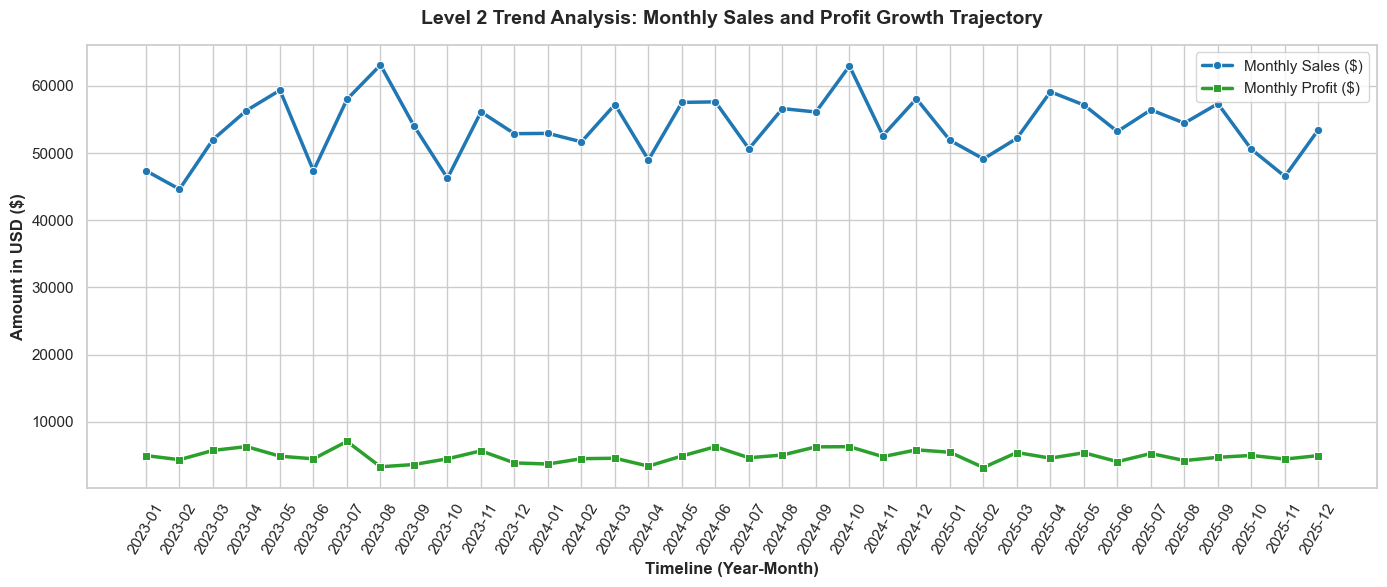

In [19]:
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order_ID'].nunique()
avg_order_value = df['Sales'].mean()
overall_margin = (total_profit / total_revenue) * 100

print("==========================================")
print("      LEVEL 1: EXECUTIVE DASHBOARD KPIS   ")
print("==========================================")
print(f"💰 Total Revenue      : ${total_revenue:,.2f}")
print(f"📈 Total Profit       : ${total_profit:,.2f}")
print(f"📊 Overall Margin     : {overall_margin:.2f}%")
print(f"📦 Total Transactions : {total_orders:,}")
print(f"🛒 Average Order Value: ${avg_order_value:,.2f}")
print("==========================================")

monthly_summary = df.groupby('Year_Month')[['Sales', 'Profit']].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_summary, x='Year_Month', y='Sales', marker='o', color='#1f77b4', linewidth=2.5, label='Monthly Sales ($)')
sns.lineplot(data=monthly_summary, x='Year_Month', y='Profit', marker='s', color='#2ca02c', linewidth=2.5, label='Monthly Profit ($)')
plt.title("Level 2 Trend Analysis: Monthly Sales and Profit Growth Trajectory", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Timeline (Year-Month)", fontweight='bold')
plt.ylabel("Amount in USD ($)", fontweight='bold')
plt.xticks(rotation=60)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

In [20]:
print("--- TRAINING RANDOM FOREST REGRESSOR ---")

ml_df = df[['Sales', 'Quantity', 'Discount', 'Category', 'Profit']].dropna()
X = pd.get_dummies(ml_df[['Sales', 'Quantity', 'Discount', 'Category']], drop_first=True)
y = ml_df['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"Model R² Accuracy Score: {r2_score(y_test, y_pred):.4f}")

feature_importance = pd.DataFrame({
    'Driver Feature': X.columns,
    'Importance Score': rf_model.feature_importances_
}).sort_values(by='Importance Score', ascending=False)

print("\nTop Core Sales & Profit Drivers:")
print(feature_importance.to_string(index=False))

--- TRAINING RANDOM FOREST REGRESSOR ---
Model R² Accuracy Score: 0.9815

Top Core Sales & Profit Drivers:
          Driver Feature  Importance Score
                   Sales          0.488954
                Discount          0.408875
     Category_Technology          0.097158
                Quantity          0.004371
Category_Office Supplies          0.000643


     LEVEL 4: IDENTIFIED HIGH-RISK AREAS  
Sub_Category   Total_Sales  Total_Profit  Avg_Discount  Profit_Margin (%)
         Art 292042.643991  24348.665744      0.154354           8.337367
      Phones 268554.578554  23543.001764      0.152140           8.766561
     Binders 266469.654854  23896.766319      0.144886           8.967913
      Tables 270068.467557  24967.943619      0.140100           9.245042
      Chairs 271496.887704  25364.166178      0.140350           9.342341
 Accessories 290034.777516  27581.040054      0.146304           9.509563
     Storage 283056.851469  27234.807663      0.145137           9.621674


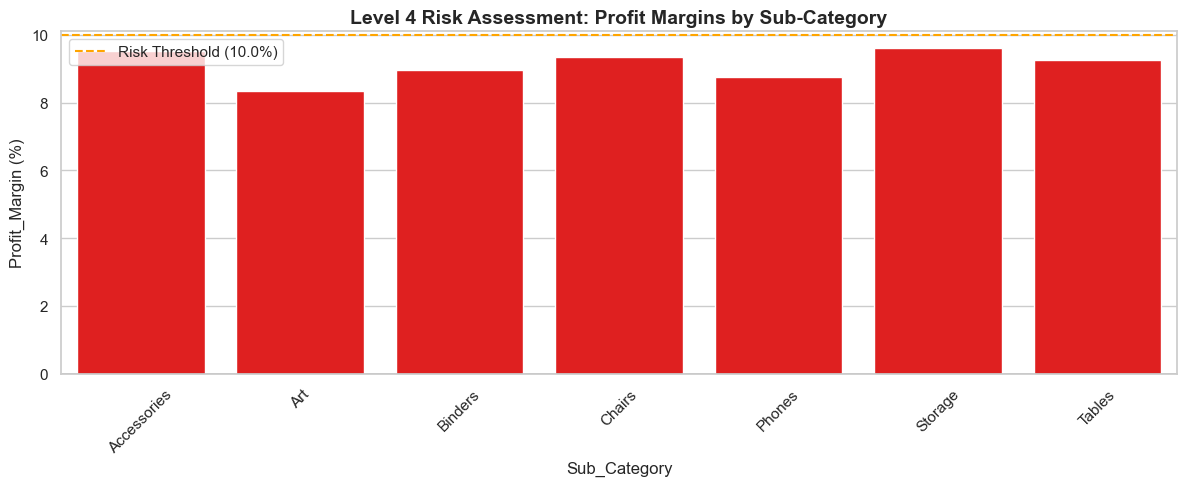

In [21]:
subcat_risk = df.groupby('Sub_Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean')
).reset_index()

subcat_risk['Profit_Margin (%)'] = (subcat_risk['Total_Profit'] / subcat_risk['Total_Sales']) * 100

risk_threshold = 10.0
high_risk_areas = subcat_risk[subcat_risk['Profit_Margin (%)'] < risk_threshold].sort_values(by='Profit_Margin (%)')

print("==========================================")
print("     LEVEL 4: IDENTIFIED HIGH-RISK AREAS  ")
print("==========================================")
print(high_risk_areas.to_string(index=False))

plt.figure(figsize=(12, 5))
colors = ['red' if m < risk_threshold else 'steelblue' for m in subcat_risk['Profit_Margin (%)']]
sns.barplot(
    data=subcat_risk, 
    x='Sub_Category', 
    y='Profit_Margin (%)', 
    hue='Sub_Category', 
    palette=colors, 
    legend=False
)
plt.axhline(0, color='black', linewidth=1)
plt.axhline(risk_threshold, color='orange', linestyle='--', label=f'Risk Threshold ({risk_threshold}%)')
plt.title("Level 4 Risk Assessment: Profit Margins by Sub-Category", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

     LEVEL 4: IDENTIFIED RISK AREAS       
Sub_Category   Total_Sales  Total_Profit  Avg_Discount  Profit_Margin (%)
         Art 210542.452743  17958.409523      0.152856           8.529591
      Chairs 211496.041588  18457.278452      0.144376           8.727009
      Tables 210880.083264  19097.588586      0.141395           9.056137
     Binders 213182.292032  19584.847473      0.143478           9.186902
 Accessories 222902.178057  20954.331273      0.144601           9.400685
     Storage 237329.989250  23129.521033      0.144409           9.745722


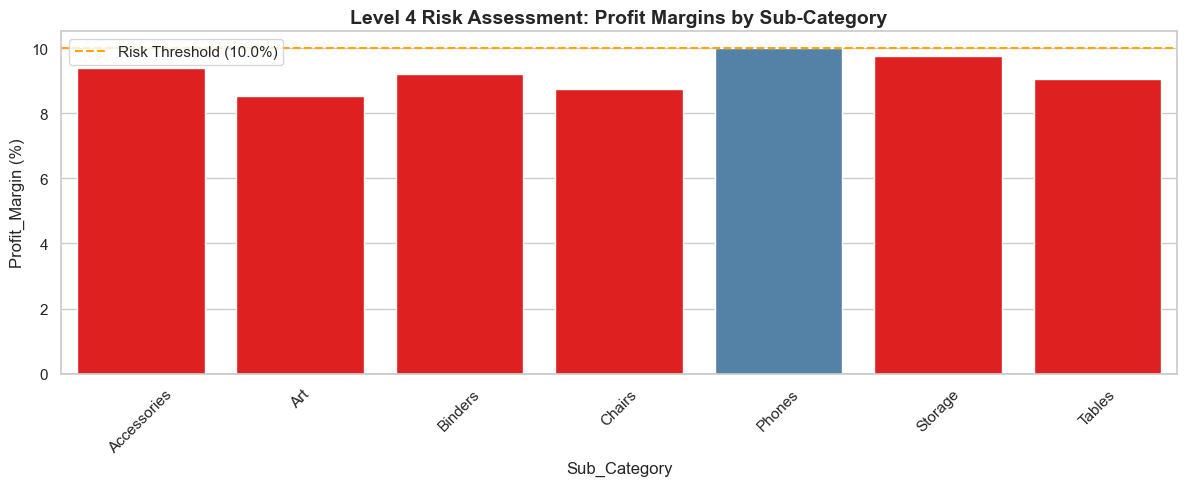

In [14]:
# Level 5: Automated Strategic Summary Generation
print("==================================================")
print("  LEVEL 5: STRATEGIC ACTION SUMMARY & ROADMAP   ")
print("==================================================")

low_margin_names = list(high_risk_areas['Sub_Category'].head(2))

print(f"1. 🛑 DISCOUNT GOVERNANCE: Machine learning feature importance highlights 'Discount' as a major volatile driver. Implement a strict threshold cap of 15% on promotional discounts to prevent bottom-line leakage.")
print(f"2. 🔍 PORTFOLIO RESTRUCTURING: Sub-categories like {low_margin_names} are exhibiting dangerous margins below {risk_threshold}%. Conduct an immediate vendor re-negotiation or price correction for these lines.")
print(f"3. 🚀 SEASONAL CAPITAL ALLOCATION: Re-allocate digital marketing budgets 4 weeks prior to proven seasonal demand spikes identified in Level 2 trends to maximize acquisition efficiency.")
print(f"4. 💼 INVENTORY OPTIMIZATION: Shift warehouse storage and capital away from high-risk, slow-moving low-margin items toward high-margin core drivers.")
print("==================================================")

  LEVEL 5: STRATEGIC ACTION SUMMARY & ROADMAP   
1. 🛑 DISCOUNT GOVERNANCE: Machine learning feature importance highlights 'Discount' as a major volatile driver. Implement a strict threshold cap of 15% on promotional discounts to prevent bottom-line leakage.
2. 🔍 PORTFOLIO RESTRUCTURING: Sub-categories like ['Art', 'Chairs'] are exhibiting dangerous margins below 10.0%. Conduct an immediate vendor re-negotiation or price correction for these lines.
3. 🚀 SEASONAL CAPITAL ALLOCATION: Re-allocate digital marketing budgets 4 weeks prior to proven seasonal demand spikes identified in Level 2 trends to maximize acquisition efficiency.
4. 💼 INVENTORY OPTIMIZATION: Shift warehouse storage and capital away from high-risk, slow-moving low-margin items toward high-margin core drivers.
